In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

(784,)


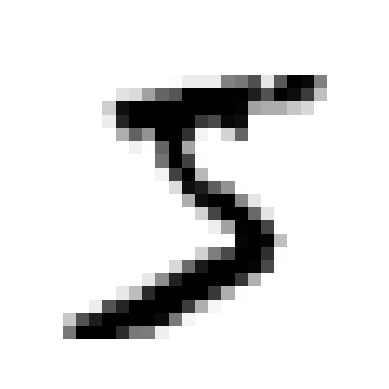

In [7]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")
plot_digit(mnist["data"][0])
print(mnist["data"][0].shape)
plt.show()
X, y = mnist["data"], mnist["target"]

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [ ]:
print(len(y_train_5), y_train_5.sum())

60000 5421


In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([X_train[0]])

array([ True])

In [ ]:
# confusion matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
cm = confusion_matrix(y_train_5, y_train_pred)
precision_score(y_train_5, y_train_pred)
recall_score(y_train_5, y_train_pred)

0.6511713705958311

curves

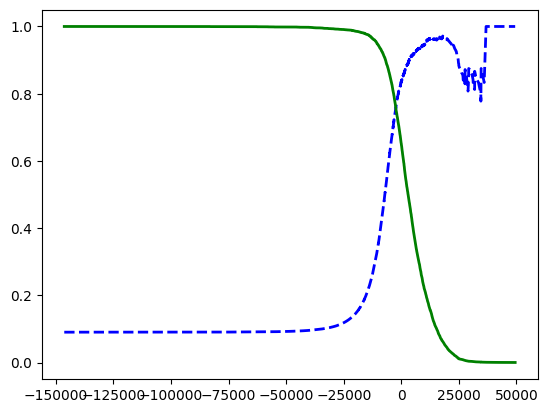

In [ ]:
from sklearn.metrics import precision_recall_curve
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.show()


In [5]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
y_train_5, y_scores_forest)

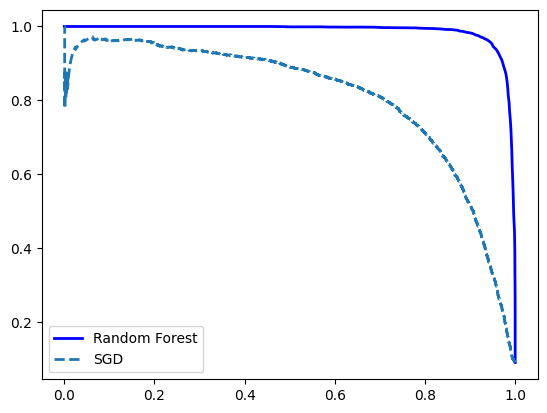

In [ ]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.legend()
plt.show()

Random Forest best

In [16]:
# DO NOT RUN THIS CELL, ITS USELESS
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score
from scipy.stats import randint

param_distribs = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 30),
    "max_features": randint(2, 20),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_distribs,
    n_iter=20,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_5)

best_model = search.best_estimator_
# {'bootstrap': False, 'max_depth': 19, 'max_features': 13, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n_estimators': 239}
y_pred = best_model.predict(X_test)

ps = precision_score(y_test_5, y_pred)
rs = recall_score(y_test_5, y_pred)

print(search.best_params_)
print(ps, rs)
# 0.9973856209150327 0.8553811659192825

KeyboardInterrupt: 

In [15]:
from sklearn.metrics import precision_score
final = RandomForestClassifier(random_state=42)
final.fit(X_train, y_train_5)
y_pred = final.predict(X_test)
ps = precision_score(y_test_5, y_pred)
rs = recall_score(y_test_5, y_pred)
print(ps, rs)
# 0.993581514762516 0.8677130044843049

0.993581514762516 0.8677130044843049


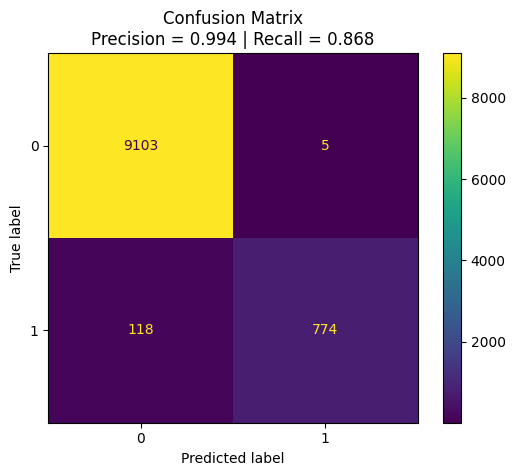

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

precision = precision_score(y_test_5, y_pred)
recall = recall_score(y_test_5, y_pred)
cm = confusion_matrix(y_test_5, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(
    f"Confusion Matrix\nPrecision = {precision:.3f} | Recall = {recall:.3f}"
)

plt.show()

In [ ]:
import joblib

joblib.dump(final, "random_forest.pkl")

NameError: name 'final' is not defined